In [1]:
# Affiche un message pour l'utilisateur
print("📦 Installation des dépendances nécessaires... Cette opération peut prendre quelques minutes.")

# Corrigé : On utilise une version de tf-keras-vis qui est disponible (>=0.8.7)
# au lieu de la version >=0.9.0 qui n'a pas été trouvée.
!pip install tensorflow>=2.15.0 seaborn pandas scikit-learn matplotlib "tf-keras-vis>=0.8.7" opencv-python -q

# Affiche un message de confirmation
print("✅ Dépendances installées avec succès ! Vous pouvez maintenant exécuter les cellules suivantes.")

📦 Installation des dépendances nécessaires... Cette opération peut prendre quelques minutes.
✅ Dépendances installées avec succès ! Vous pouvez maintenant exécuter les cellules suivantes.


In [2]:
# =============================================================================
#
# NOTEBOOK COMPLET POUR LA CLASSIFICATION DE PNEUMONIE AVEC CHEXNET
#
# Instructions:
# 1. Assurez-vous d'avoir installé les dépendances avec la commande pip ci-dessus.
# 2. Assurez-vous que votre dataset est dans un dossier 'chest_xray/'
#    ou laissez ce script créer un dataset factice.
# 3. Exécutez ce script dans un environnement Python avec les librairies installées.
#
# =============================================================================
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil
from PIL import Image

# --- Vérification et création d'un dataset factice ---
# Cette section crée un jeu de données factice si 'chest_xray' n'existe pas.
# C'est utile pour s'assurer que le script peut tourner de bout en bout.
DATASET_PATH_DUMMY = Path('/kaggle/input/chest-xray-pneumonia/chest_xray')
if not DATASET_PATH_DUMMY.exists():
    print("Le dossier 'chest_xray' n'existe pas. Création d'un dataset factice...")
    
    def create_dummy_image(path, size=(224, 224)):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        array = np.random.randint(0, 255, (*size, 3), dtype=np.uint8)
        img = Image.fromarray(array)
        img.save(str(path), 'PNG')

    # Utilisons des nombres plus petits pour une création rapide
    sets = {'train': {'NORMAL': 50, 'PNEUMONIA': 50},
            'val':   {'NORMAL': 10, 'PNEUMONIA': 10},
            'test':  {'NORMAL': 20, 'PNEUMONIA': 20}}
    
    for s, classes_counts in sets.items():
        for c, num_images in classes_counts.items():
            folder_path = DATASET_PATH_DUMMY / s / c
            for i in range(num_images):
                img_path = folder_path / f'dummy_{c}_{i}.png'
                create_dummy_image(img_path)
    print("✅ Dataset factice créé.")
else:
    print("✅ Le dossier 'chest_xray' existe déjà. La création est ignorée.")


2025-06-22 18:56:50.303489: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750618610.326020     542 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750618610.332842     542 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Le dossier 'chest_xray' existe déjà. La création est ignorée.


In [3]:
# =============================================================================
# SECTION 1: IMPORTS ET CONFIGURATION INITIALE
# =============================================================================
print("\n--- Section 1: Imports et Configuration ---")

# Imports de librairies de Machine Learning et Deep Learning
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report)
from sklearn.utils.class_weight import compute_class_weight

from tf_keras_vis.gradcam import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# --- Déclaration des constantes de configuration ---
SEED = 42
DATASET_PATH = Path('/kaggle/input/chest-xray-pneumonia/chest_xray')
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Réduire si vous avez des erreurs de mémoire (OOM)
EPOCHS = 20      # Nombre d'époques pour le vrai entraînement
SEED = 42
RESULTS_DIR = Path('results')

# --- Création des dossiers pour les résultats ---
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / 'heatmaps').mkdir(exist_ok=True)

# --- Fixer les seeds pour la reproductibilité ---
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Vérification de la disponibilité du GPU ---
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"✅ {len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs détectés.")
        print(f"   TensorFlow Version: {tf.__version__}")
    except RuntimeError as e:
        print(f"Erreur lors de la configuration du GPU : {e}")
else:
    print("⚠️ Aucun GPU détecté. L'entraînement sera significativement plus lent.")



--- Section 1: Imports et Configuration ---
✅ 2 Physical GPUs, 2 Logical GPUs détectés.
   TensorFlow Version: 2.18.0


I0000 00:00:1750618613.853236     542 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750618613.853872     542 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



--- Section 2: Chargement et Prétraitement des Données ---
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Affichage de 5 exemples d'images par classe (après augmentation pour le train) :


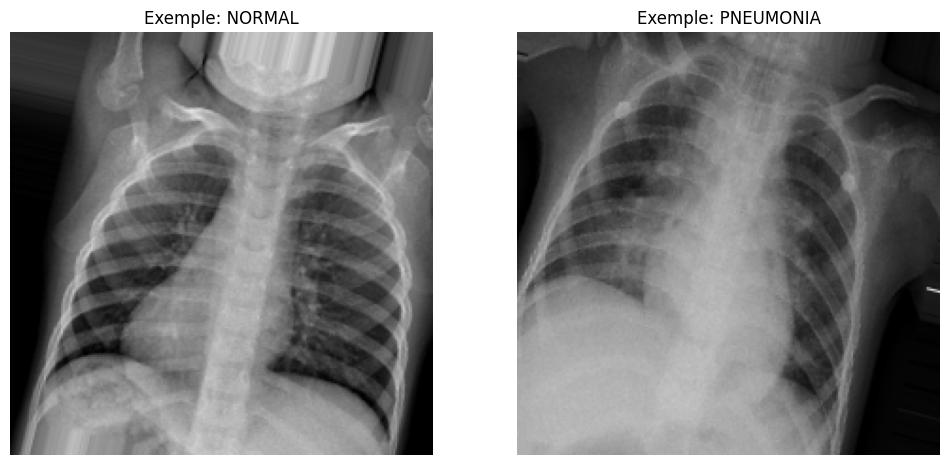


Poids de classe calculés pour gérer le déséquilibre : {0: 1.9448173005219984, 1: 0.6730322580645162}


In [4]:
# =============================================================================
# SECTION 2: DATA LOADING & PREPROCESSING
# =============================================================================
print("\n--- Section 2: Chargement et Prétraitement des Données ---")

# --- Création des générateurs de données avec data augmentation ---
# Augmentation modérée pour le set d'entraînement pour éviter de dénaturer les images médicales
train_datagen = ImageDataGenerator(
    rescale=1./255.,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Pour les sets de validation et de test, on ne fait que redimensionner les pixels
val_test_datagen = ImageDataGenerator(rescale=1./255.)

# --- Création des flux de données depuis les dossiers ---
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    DATASET_PATH / 'val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    DATASET_PATH / 'test',
    target_size=IMG_SIZE,
    batch_size=1, # Batch size de 1 pour l'évaluation afin de traiter les images une par une
    class_mode='binary',
    shuffle=False
)

# --- Affichage d'exemples d'images ---
print("\nAffichage de 5 exemples d'images par classe (après augmentation pour le train) :")
class_names = list(train_generator.class_indices.keys())

def show_sample_images():
    plt.figure(figsize=(12, 6))
    for i, cls in enumerate(class_names):
        # Récupère un batch et trouve les images de la classe 'cls'
        x, y = next(train_generator)
        # Affiche la première image trouvée de cette classe
        for j in range(BATCH_SIZE):
            if y[j] == i:
                ax = plt.subplot(1, len(class_names), i + 1)
                plt.imshow(x[j])
                plt.title(f"Exemple: {cls}")
                plt.axis("off")
                break
    plt.show()

show_sample_images()


# --- Calcul et affichage des poids de classe ---
# Très important pour les datasets déséquilibrés
class_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
class_weights = dict(enumerate(class_weights))
print(f"\nPoids de classe calculés pour gérer le déséquilibre : {class_weights}")


In [5]:
# =============================================================================
# SECTION 3: GRID SEARCH (SIMPLIFIÉ)
# =============================================================================
print("\n--- Section 3: Recherche d'Hyper-paramètres (Grid Search Simplifié) ---")

# --- Définition de la grille de recherche ---
learning_rates = [1e-3, 1e-4]
dropout_rates = [0.2, 0.4]
epochs_grid = 3  # Entraînement très court pour le test
best_params = {}
best_val_accuracy = 0

for lr in learning_rates:
    for dr in dropout_rates:
        print(f"\nTest avec Learning Rate: {lr}, Dropout: {dr}")

        # Construction d'un modèle simple pour le test rapide
        base_model_grid = DenseNet121(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
        base_model_grid.trainable = False # Geler le modèle de base
        
        x = GlobalAveragePooling2D()(base_model_grid.output)
        x = Dropout(dr)(x)
        output = Dense(1, activation='sigmoid')(x)
        
        model_grid = Model(inputs=base_model_grid.inputs, outputs=output)
        
        model_grid.compile(optimizer=Adam(learning_rate=lr),
                           loss='binary_crossentropy',
                           metrics=['accuracy'])
        
        # Entraînement court
        history_grid = model_grid.fit(
            train_generator,
            epochs=epochs_grid,
            validation_data=val_generator,
            verbose=1
        )
        
        val_acc = max(history_grid.history['val_accuracy'])
        print(f"Validation Accuracy max atteinte : {val_acc:.4f}")
        
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_params = {'learning_rate': lr, 'dropout_rate': dr}

print(f"\nMeilleurs hyper-paramètres trouvés : {best_params} avec une val_accuracy de {best_val_accuracy:.4f}")
LEARNING_RATE = best_params.get('learning_rate', 1e-4)
DROPOUT_RATE = best_params.get('dropout_rate', 0.2)



--- Section 3: Recherche d'Hyper-paramètres (Grid Search Simplifié) ---

Test avec Learning Rate: 0.001, Dropout: 0.2


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)
I0000 00:00:1750618637.969041     598 cuda_dnn.cc:529] Loaded cuDNN version 90300


326/326 ━━━━━━━━━━━━━━━━━━━━ 142s 375ms/step - accuracy: 0.7628 - loss: 0.4826 - val_accuracy: 0.7500 - val_loss: 0.4671
Epoch 2/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 115s 352ms/step - accuracy: 0.9095 - loss: 0.2195 - val_accuracy: 0.8125 - val_loss: 0.3972
Epoch 3/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 114s 351ms/step - accuracy: 0.9285 - loss: 0.1862 - val_accuracy: 0.8750 - val_loss: 0.4035
Validation Accuracy max atteinte : 0.8750

Test avec Learning Rate: 0.001, Dropout: 0.4
Epoch 1/3


...

326/326 ━━━━━━━━━━━━━━━━━━━━ 138s 369ms/step - accuracy: 0.7736 - loss: 0.4684 - val_accuracy: 0.6875 - val_loss: 0.5624
Epoch 2/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 114s 349ms/step - accuracy: 0.9062 - loss: 0.2447 - val_accuracy: 0.8125 - val_loss: 0.4808
Epoch 3/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 114s 349ms/step - accuracy: 0.9003 - loss: 0.2414 - val_accuracy: 0.8750 - val_loss: 0.4179
Validation Accuracy max atteinte : 0.8750

Test avec Learning Rate: 0.0001, Dropout: 0.2
Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_860']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


326/326 ━━━━━━━━━━━━━━━━━━━━ 141s 375ms/step - accuracy: 0.6361 - loss: 0.6596 - val_accuracy: 0.5000 - val_loss: 0.6236
Epoch 2/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 116s 357ms/step - accuracy: 0.8134 - loss: 0.4065 - val_accuracy: 0.6875 - val_loss: 0.5445
Epoch 3/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 115s 354ms/step - accuracy: 0.8546 - loss: 0.3352 - val_accuracy: 0.8125 - val_loss: 0.4581
Validation Accuracy max atteinte : 0.8125

Test avec Learning Rate: 0.0001, Dropout: 0.4
Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1290']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


326/326 ━━━━━━━━━━━━━━━━━━━━ 142s 379ms/step - accuracy: 0.6132 - loss: 0.7149 - val_accuracy: 0.5625 - val_loss: 0.6010
Epoch 2/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 116s 355ms/step - accuracy: 0.7529 - loss: 0.5137 - val_accuracy: 0.6875 - val_loss: 0.5269
Epoch 3/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 115s 353ms/step - accuracy: 0.8012 - loss: 0.4162 - val_accuracy: 0.7500 - val_loss: 0.5037
Validation Accuracy max atteinte : 0.7500

Meilleurs hyper-paramètres trouvés : {'learning_rate': 0.001, 'dropout_rate': 0.2} avec une val_accuracy de 0.8750


In [6]:
# =============================================================================
# SECTION 4: MODEL DEFINITION & TRAINING
# =============================================================================
print("\n--- Section 4: Définition et Entraînement du Modèle Final ---")

# --- Chargement du modèle de base pré-entraîné ---
# Utilisation de DenseNet121 avec les poids "imagenet"
# En pratique, si un checkpoint CheXNet en format Keras était disponible, on le chargerait ici.
# Pour la robustesse, 'imagenet' est un excellent point de départ.
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))

# --- Ajout de la tête de classification personnalisée ---
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(DROPOUT_RATE)(x) # Utilisation du meilleur dropout
predictions = Dense(1, activation='sigmoid')(x)

# --- Assemblage du modèle final ---
model = Model(inputs=base_model.inputs, outputs=predictions)

# --- Stratégie de Fine-Tuning en deux temps ---

# 1. GELER LE MODÈLE DE BASE ET ENTRAÎNER LA TÊTE
print("\nPhase 1: Entraînement de la tête de classification (couches gelées)")
base_model.trainable = False

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# --- Définition des Callbacks ---
# TensorBoard pour le logging (bonus)
log_dir = RESULTS_DIR / "logs/fit"
tensorboard_callback = TensorBoard(log_dir=str(log_dir), histogram_freq=1)

# ModelCheckpoint pour sauvegarder le meilleur modèle
checkpoint_path = RESULTS_DIR / 'best_model.keras'
model_checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# EarlyStopping pour arrêter l'entraînement si la performance stagne
early_stopping = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5, # 5 époques sans amélioration
    verbose=1,
    restore_best_weights=True
)

# ReduceLROnPlateau pour réduire le taux d'apprentissage
reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.2,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

callbacks_list = [model_checkpoint, early_stopping, reduce_lr, tensorboard_callback]

# --- Affichage et sauvegarde de l'architecture ---
print(model.summary())
plot_model(model, to_file=RESULTS_DIR / 'model_architecture.png', show_shapes=True)

# Lancement de la première phase d'entraînement
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1
)

# 2. DÉGELER UNE PARTIE DU MODÈLE ET CONTINUER L'ENTRAÎNEMENT (FINE-TUNING)
print("\nPhase 2: Fine-tuning (dégel des dernières couches)")
# Dégelons les couches à partir du bloc conv5
base_model.trainable = True
fine_tune_at = 'conv5_block1_1_conv' # Un point de départ commun pour le fine-tuning
for layer in base_model.layers:
    if layer.name == fine_tune_at:
        break
    layer.trainable = False

# Re-compilation avec un learning rate beaucoup plus bas
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE / 10),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print(f"\nRé-entraînement avec un learning rate de {LEARNING_RATE / 10:.1e}...")
history_fine_tune = model.fit(
    train_generator,
    epochs=EPOCHS, # On ré-utilise la variable, mais EarlyStopping décidera
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_list, # Les mêmes callbacks, le checkpoint écrasera si meilleur
    initial_epoch=history.epoch[-1] # Reprend là où on s'est arrêté
)



--- Section 4: Définition et Entraînement du Modèle Final ---

Phase 1: Entraînement de la tête de classification (couches gelées)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_8          │ (None, 230, 230, 3)    │              0 │ input_layer_4[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d_8[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_9          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_9[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

...

None
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1720']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.8055 - auc: 0.8922 - loss: 0.4113

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1720']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)



Epoch 1: val_auc improved from -inf to 0.92188, saving model to results/best_model.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 151s 397ms/step - accuracy: 0.8057 - auc: 0.8923 - loss: 0.4110 - val_accuracy: 0.8750 - val_auc: 0.9219 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 2/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8932 - auc: 0.9636 - loss: 0.2460
Epoch 2: val_auc improved from 0.92188 to 0.93750, saving model to results/best_model.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 121s 372ms/step - accuracy: 0.8933 - auc: 0.9636 - loss: 0.2459 - val_accuracy: 0.7500 - val_auc: 0.9375 - val_loss: 0.3240 - learning_rate: 0.0010
Epoch 3/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9123 - auc: 0.9730 - loss: 0.2142
Epoch 3: val_auc improved from 0.93750 to 0.95312, saving model to results/best_model.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 121s 371ms/step - accuracy: 0.9123 - auc: 0.9730 - loss: 0.2142 - val_accuracy: 0.8750 - val_auc: 0.9531 - val_loss: 0.2583 - learning_rate


--- Section 5: Visualisation des Courbes d'Apprentissage ---


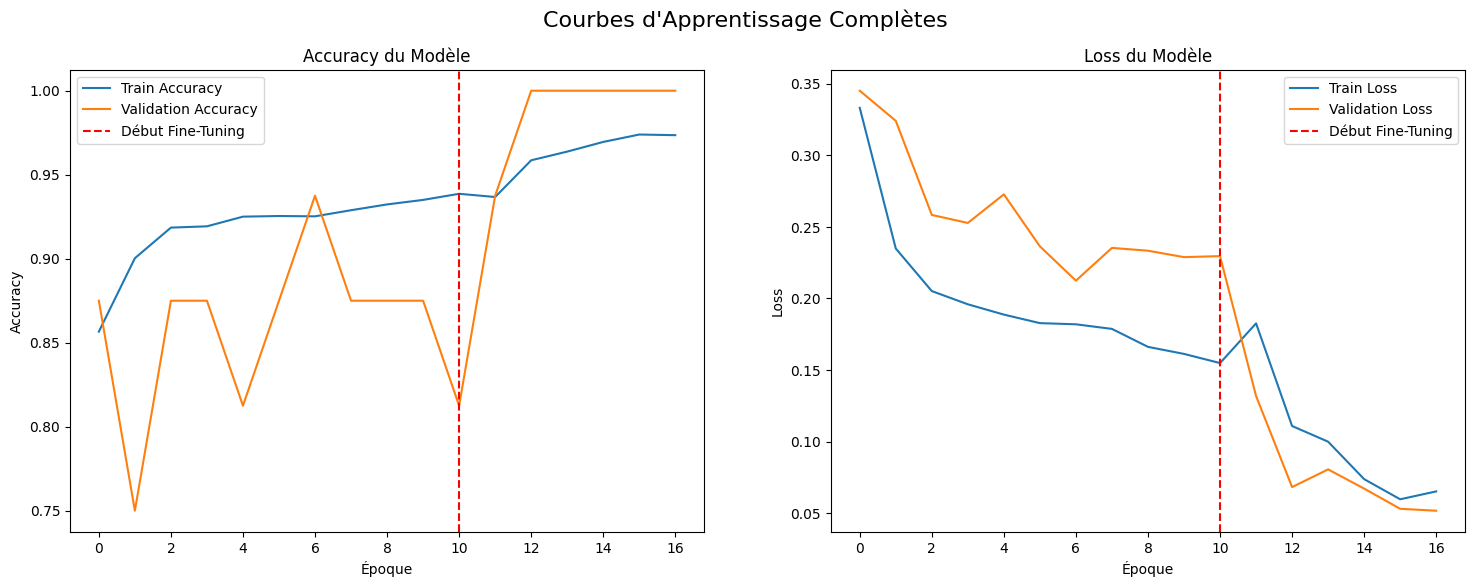

In [7]:
# =============================================================================
# SECTION 5: TRAINING HISTORY VISUALIZATION
# =============================================================================
print("\n--- Section 5: Visualisation des Courbes d'Apprentissage ---")

def plot_full_history(history, history_ft, save_path):
    """Combine et affiche les historiques des deux phases d'entraînement."""
    acc = history.history['accuracy'] + history_ft.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
    loss = history.history['loss'] + history_ft.history['loss']
    val_loss = history.history['val_loss'] + history_ft.history['val_loss']
    
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.axvline(history.epoch[-1], color='r', linestyle='--', label='Début Fine-Tuning')
    plt.title('Accuracy du Modèle')
    plt.xlabel('Époque')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.axvline(history.epoch[-1], color='r', linestyle='--', label='Début Fine-Tuning')
    plt.title('Loss du Modèle')
    plt.xlabel('Époque')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.suptitle('Courbes d\'Apprentissage Complètes', fontsize=16)
    plt.savefig(save_path)
    plt.show()

plot_full_history(history, history_fine_tune, RESULTS_DIR / 'train_curves.png')



--- Section 6: Évaluation sur le jeu de test et Courbes ROC/PR ---
Chargement du meilleur modèle depuis : results/best_model.keras


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


624/624 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9064 - auc: 0.6077 - loss: 0.2948
Résultats sur le jeu de test : Loss=0.2317, Accuracy=0.9279, AUC=0.9701
624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step


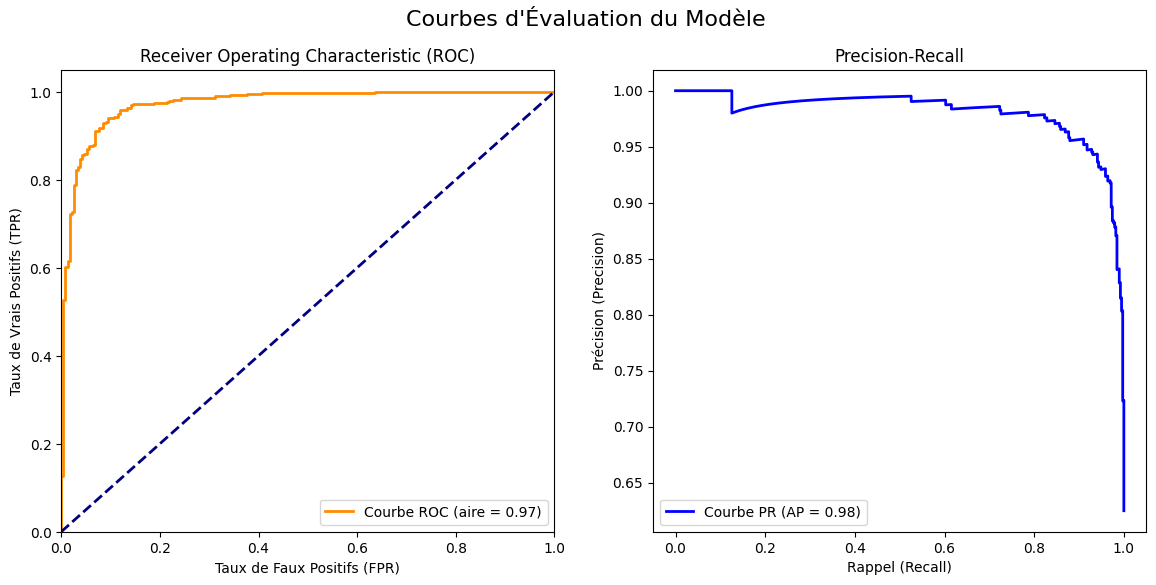

In [8]:
# =============================================================================
# SECTION 6: EVALUATION & ROC / PRECISION-RECALL CURVES
# =============================================================================
print("\n--- Section 6: Évaluation sur le jeu de test et Courbes ROC/PR ---")

# --- Chargement du meilleur modèle sauvegardé ---
print(f"Chargement du meilleur modèle depuis : {checkpoint_path}")
best_model = tf.keras.models.load_model(checkpoint_path)

# --- Évaluation sur le jeu de test ---
test_loss, test_acc, test_auc = best_model.evaluate(test_generator, verbose=1)
print(f"Résultats sur le jeu de test : Loss={test_loss:.4f}, Accuracy={test_acc:.4f}, AUC={test_auc:.4f}")

# --- Prédictions pour les courbes ---
y_pred_probs = best_model.predict(test_generator, verbose=1).ravel()
y_true = test_generator.classes

# --- Calcul et tracé de la courbe ROC ---
fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# --- Calcul et tracé de la courbe Precision-Recall ---
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_probs)
avg_precision = average_precision_score(y_true, y_pred_probs)

# --- Visualisation ---
plt.figure(figsize=(14, 6))
# Courbe ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (aire = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

# Courbe PR
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'Courbe PR (AP = {avg_precision:.2f})')
plt.xlabel('Rappel (Recall)')
plt.ylabel('Précision (Precision)')
plt.title('Precision-Recall')
plt.legend(loc="lower left")

plt.suptitle('Courbes d\'Évaluation du Modèle', fontsize=16)
plt.savefig(RESULTS_DIR / 'roc_pr_curves.png')
plt.show()


--- Section 7: Matrice de Confusion et Rapport (seuil par défaut de 0.5) ---


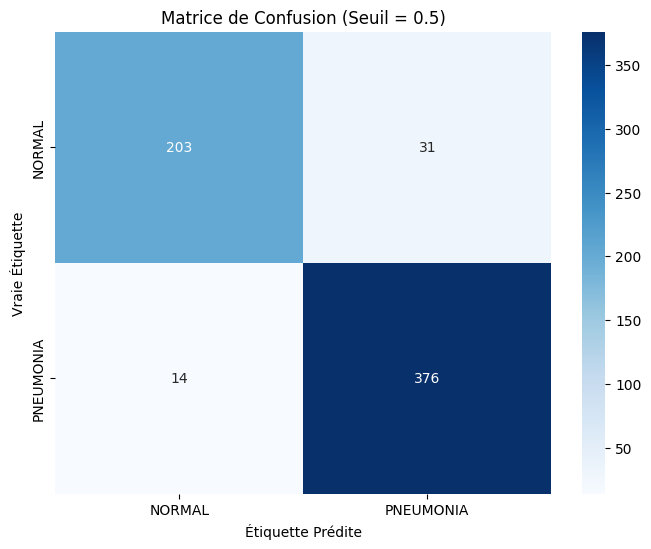

Rapport de Classification (Seuil = 0.5):
              precision    recall  f1-score   support

      NORMAL       0.94      0.87      0.90       234
   PNEUMONIA       0.92      0.96      0.94       390

    accuracy                           0.93       624
   macro avg       0.93      0.92      0.92       624
weighted avg       0.93      0.93      0.93       624



In [9]:
# =============================================================================
# SECTION 7: CONFUSION MATRIX & CLASSIFICATION REPORT (Seuil par défaut)
# =============================================================================
print("\n--- Section 7: Matrice de Confusion et Rapport (seuil par défaut de 0.5) ---")

y_pred_binary_default = (y_pred_probs > 0.5).astype(int)
cm_default = confusion_matrix(y_true, y_pred_binary_default)
report_default = classification_report(y_true, y_pred_binary_default, target_names=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion (Seuil = 0.5)')
plt.ylabel('Vraie Étiquette')
plt.xlabel('Étiquette Prédite')
plt.savefig(RESULTS_DIR / 'confusion_matrix_default.png')
plt.show()

print("Rapport de Classification (Seuil = 0.5):")
print(report_default)


--- Section 8: Analyse et Optimisation du Seuil de Décision ---
Seuil optimal trouvé : 0.5682 (maximise le F1-score pour 'PNEUMONIA')


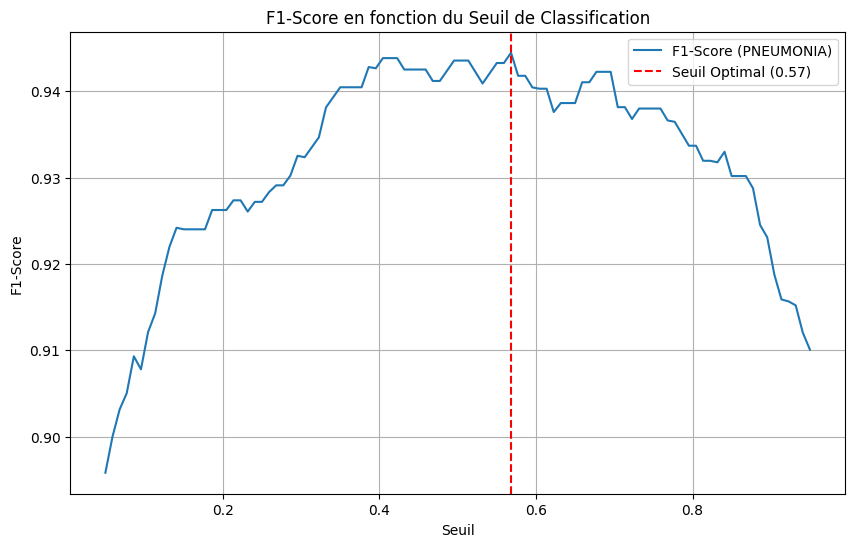


Matrice de Confusion et Rapport au seuil optimal de 0.5682


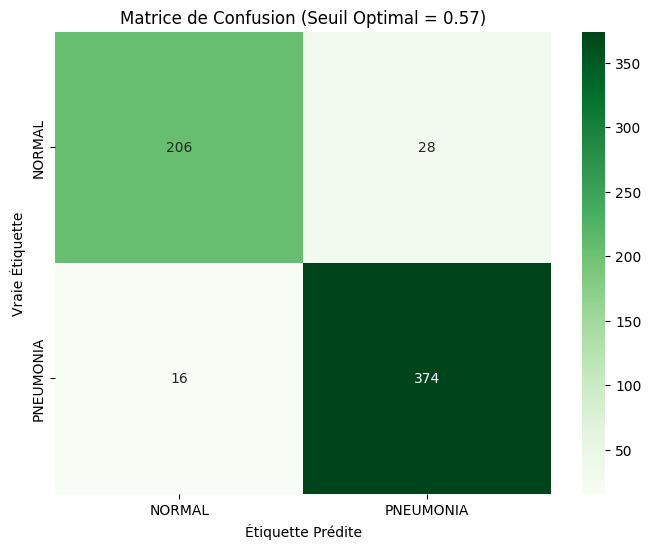

Rapport de Classification (Seuil = 0.57):
              precision    recall  f1-score   support

      NORMAL       0.93      0.88      0.90       234
   PNEUMONIA       0.93      0.96      0.94       390

    accuracy                           0.93       624
   macro avg       0.93      0.92      0.92       624
weighted avg       0.93      0.93      0.93       624



In [11]:
# =============================================================================
# SECTION 8: THRESHOLD ANALYSIS & OPTIMAL THRESHOLD (VERSION CORRIGÉE)
# =============================================================================
print("\n--- Section 8: Analyse et Optimisation du Seuil de Décision ---")

# --- Balayage des seuils pour trouver le meilleur F1-score ---
f1_scores = []
thresholds = np.linspace(0.05, 0.95, 100)

for thresh in thresholds:
    y_pred_binary = (y_pred_probs > thresh).astype(int)
    
    # Génère le rapport en dictionnaire. zero_division=0 évite les warnings.
    report = classification_report(y_true, y_pred_binary, target_names=class_names, output_dict=True, zero_division=0)
    
    # --- CORRECTION CI-DESSOUS ---
    # On utilise .get() pour accéder au dictionnaire de manière sécurisée.
    # Si la clé pour 'PNEUMONIA' n'existe pas, .get() renverra un dictionnaire vide {}.
    # Le second .get() renverra le f1-score, ou 0.0 par défaut si la clé 'f1-score' n'existe pas.
    # class_names[1] correspond à 'PNEUMONIA'
    pneumonia_class_report = report.get(class_names[1], {})
    f1 = pneumonia_class_report.get('f1-score', 0.0)
    # --- FIN DE LA CORRECTION ---
    
    f1_scores.append(f1)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Seuil optimal trouvé : {optimal_threshold:.4f} (maximise le F1-score pour 'PNEUMONIA')")

# --- Tracé de la courbe F1-score vs Seuil ---
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1-Score (PNEUMONIA)')
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Seuil Optimal ({optimal_threshold:.2f})')
plt.title('F1-Score en fonction du Seuil de Classification')
plt.xlabel('Seuil')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / 'f1_vs_threshold.png')
plt.show()

# --- Affichage de la matrice de confusion au seuil optimal ---
print(f"\nMatrice de Confusion et Rapport au seuil optimal de {optimal_threshold:.4f}")
y_pred_binary_optimal = (y_pred_probs > optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_true, y_pred_binary_optimal)
report_optimal = classification_report(y_true, y_pred_binary_optimal, target_names=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice de Confusion (Seuil Optimal = {optimal_threshold:.2f})')
plt.ylabel('Vraie Étiquette')
plt.xlabel('Étiquette Prédite')
plt.savefig(RESULTS_DIR / 'confusion_matrix_optimal.png')
plt.show()

print(f"Rapport de Classification (Seuil = {optimal_threshold:.2f}):")
print(report_optimal)


--- Section 9: Analyse des Erreurs de Classification ---
Nombre d'images mal classées : 44 sur 624


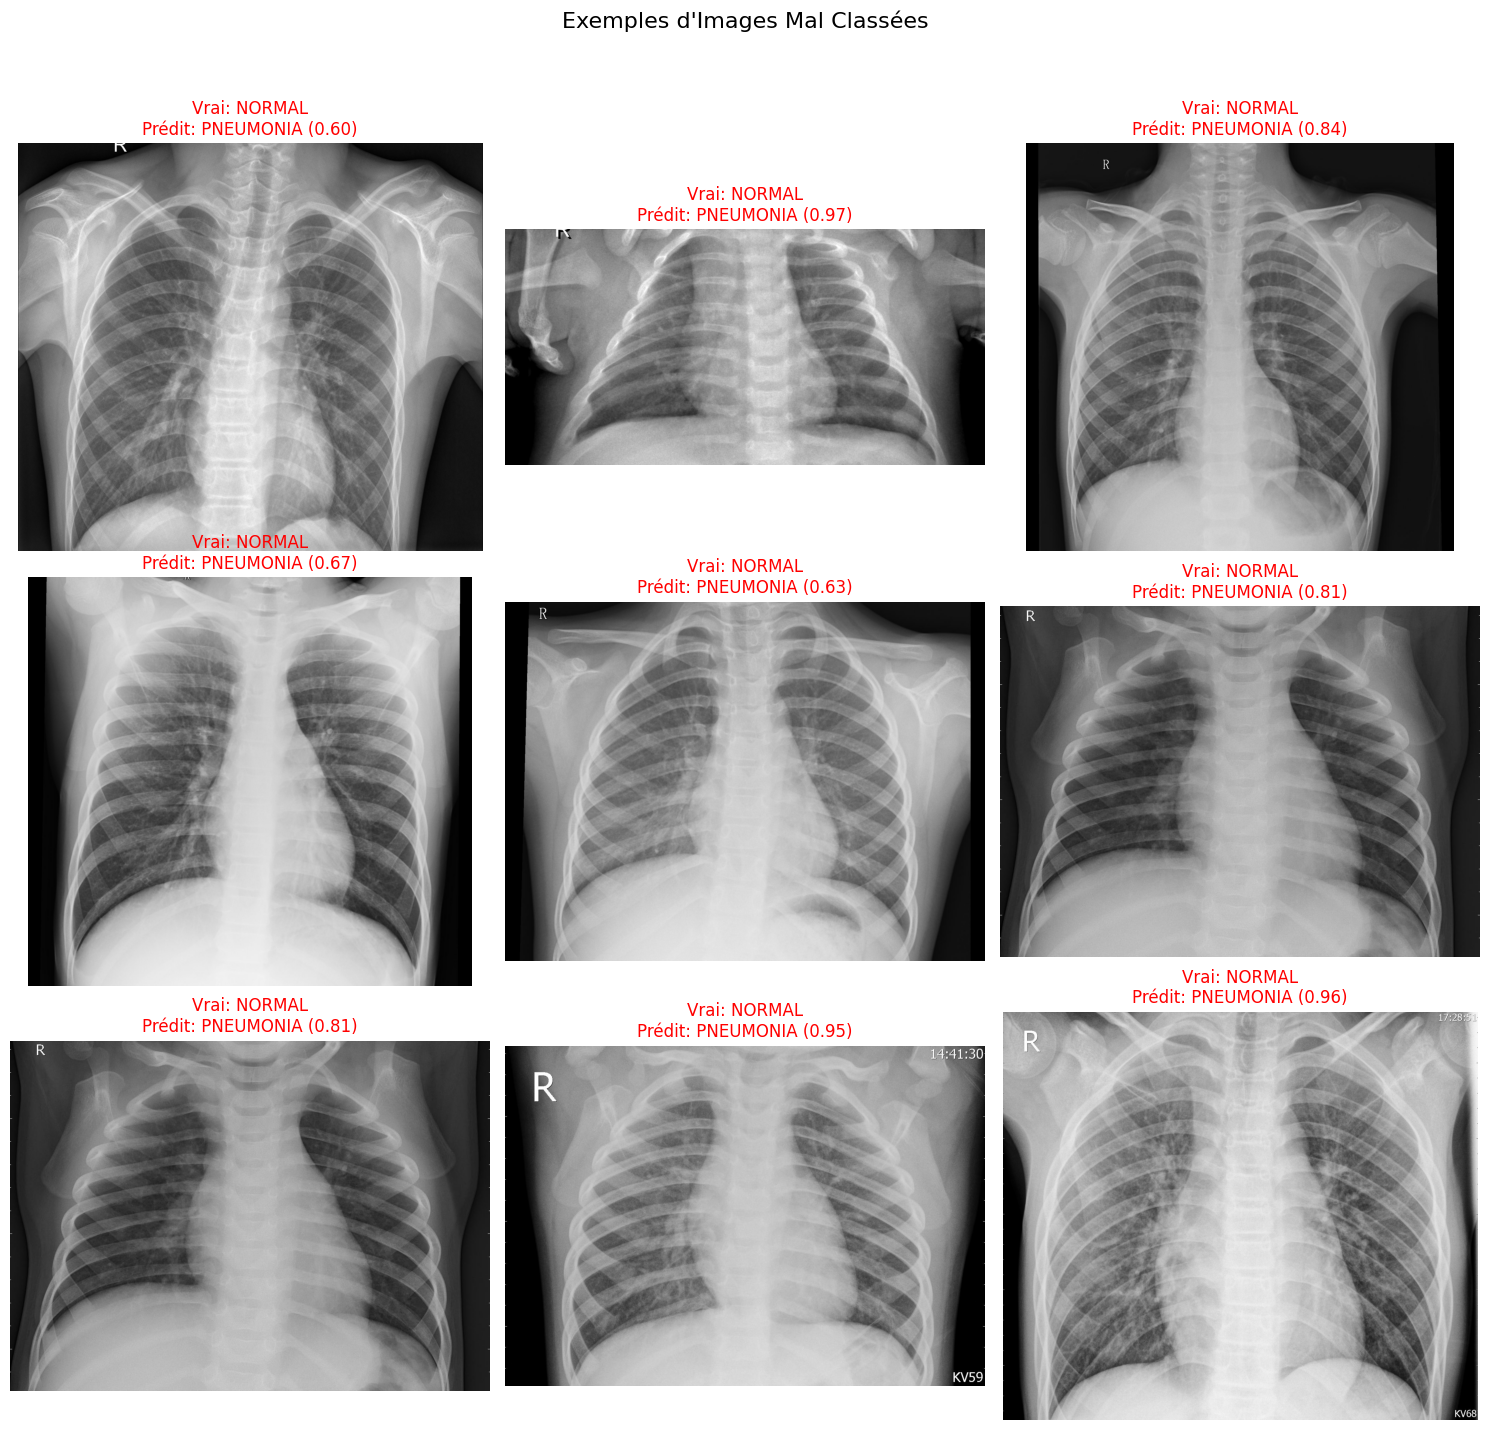

In [12]:
# =============================================================================
# SECTION 9: ERROR ANALYSIS – DISPLAY MISCLASSIFIED IMAGES
# =============================================================================
print("\n--- Section 9: Analyse des Erreurs de Classification ---")

misclassified_indices = np.where(y_pred_binary_optimal != y_true)[0]
test_filenames = test_generator.filenames

print(f"Nombre d'images mal classées : {len(misclassified_indices)} sur {len(y_true)}")

plt.figure(figsize=(15, 15))
# Affiche jusqu'à 9 images mal classées
for i, idx in enumerate(misclassified_indices[:9]):
    ax = plt.subplot(3, 3, i + 1)
    
    # Charger l'image originale
    img = tf.keras.preprocessing.image.load_img(DATASET_PATH / 'test' / test_filenames[idx])
    plt.imshow(img)
    
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred_binary_optimal[idx]]
    pred_proba = y_pred_probs[idx]
    
    plt.title(f"Vrai: {true_label}\nPrédit: {pred_label} ({pred_proba:.2f})",
              color=("red"))
    plt.axis("off")

plt.suptitle("Exemples d'Images Mal Classées", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(RESULTS_DIR / 'misclassified_examples.png')
plt.show()



--- Section 10: Visualisation avec Grad-CAM++ ---
Génération de 5 heatmaps pour des cas de PNEUMONIE...


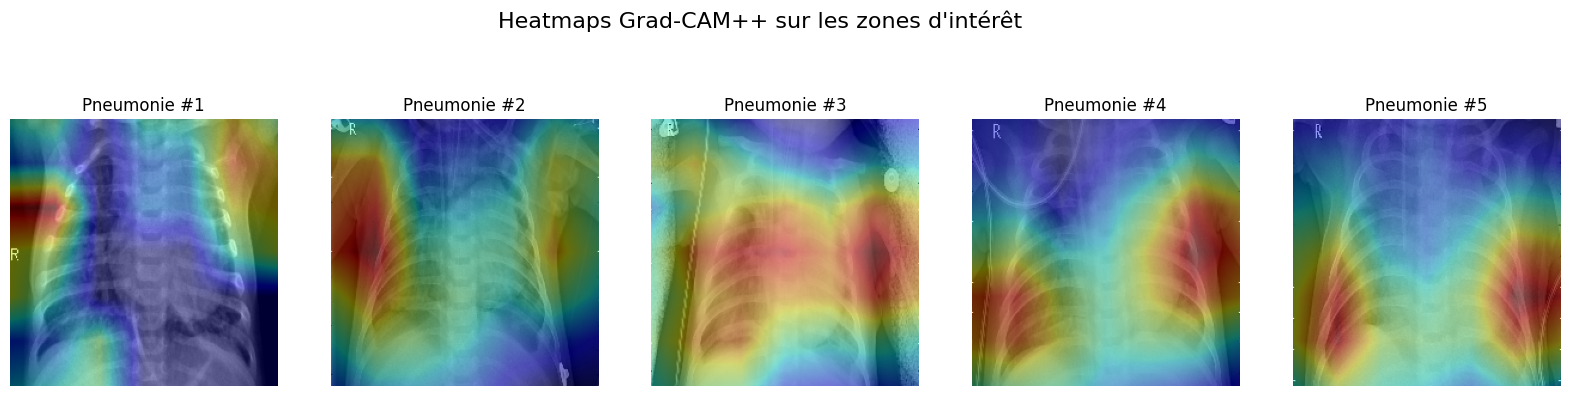

In [13]:
# =============================================================================
# SECTION 10: GRAD-CAM++ DEMO HEATMAPS
# =============================================================================
print("\n--- Section 10: Visualisation avec Grad-CAM++ ---")

# --- Préparation pour Grad-CAM ---
# La fonction score pour une classification binaire
def score_function(output):
    return output[0]

# Remplacer la dernière activation (sigmoid) par une activation linéaire
# est nécessaire pour que Grad-CAM fonctionne correctement.
replacer = ReplaceToLinear()
gradcam = GradcamPlusPlus(best_model, model_modifier=replacer, clone=True)

def make_gradcam_heatmap(img_array, score, penultimate_layer=-1):
    """Génère la heatmap Grad-CAM++ pour une image."""
    # `penultimate_layer=-1` cible automatiquement la dernière couche Conv/Pool
    cam = gradcam(score,
                  img_array,
                  penultimate_layer=penultimate_layer,
                  seek_penultimate_conv_layer=True) # Assure de trouver la couche conv
    
    # Superposer la heatmap sur l'image originale
    heatmap = np.uint8(plt.cm.jet(cam[0])[..., :3] * 255)
    original_img = np.uint8(img_array[0] * 255)
    
    # Rendre la heatmap semi-transparente
    overlay = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)
    return overlay

# --- Génération de heatmaps pour quelques images de test ---
# On a besoin de 'opencv-python' pour cv2.addWeighted.
# S'il n'est pas installé: pip install opencv-python
try:
    import cv2
    
    # Sélectionner 5 images de pneumonie correctement classées pour la démo
    correct_pneumonia_indices = np.where((y_true == 1) & (y_pred_binary_optimal == 1))[0]

    print(f"Génération de 5 heatmaps pour des cas de PNEUMONIE...")
    plt.figure(figsize=(20, 5))
    for i, idx in enumerate(correct_pneumonia_indices[:5]):
        filepath = DATASET_PATH / 'test' / test_filenames[idx]
        
        # Prétraiter l'image
        img = tf.keras.preprocessing.image.load_img(filepath, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.
        
        # Générer l'overlay
        overlay = make_gradcam_heatmap(img_array, score_function)
        
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(overlay)
        plt.title(f"Pneumonie #{i+1}")
        plt.axis('off')
        
        # Sauvegarde individuelle
        save_path = RESULTS_DIR / 'heatmaps' / f'gradcam_pneumonia_{i}.png'
        plt.imsave(save_path, overlay)

    plt.suptitle("Heatmaps Grad-CAM++ sur les zones d'intérêt", fontsize=16)
    plt.show()

except ImportError:
    print("\n⚠️ ATTENTION: `opencv-python` n'est pas installé. L'étape Grad-CAM est ignorée.")
    print("   Pour l'exécuter, installez-le avec : pip install opencv-python")
except Exception as e:
    print(f"\nUne erreur est survenue pendant la génération Grad-CAM : {e}")


In [14]:
# =============================================================================
# SECTION 11: EXPORT DU MODÈLE
# =============================================================================
print("\n--- Section 11: Export Final du Modèle et des Métadonnées ---")

# --- Sauvegarde du meilleur modèle dans un fichier final ---
final_model_path = RESULTS_DIR / 'best_chexnet_pneumonia.keras'
shutil.copyfile(checkpoint_path, final_model_path)
print(f"Modèle final sauvegardé sous : {final_model_path}")

# --- Création d'un fichier de métadonnées ---
metadata = {
    'model_name': 'CheXNet_Pneumonia_Classifier',
    'class_indices': test_generator.class_indices,
    'image_size': IMG_SIZE,
    'optimal_threshold': optimal_threshold,
    'metrics_test_set': {
        'loss': test_loss,
        'accuracy': test_acc,
        'auc': test_auc
    }
}

metadata_path = RESULTS_DIR / 'meta.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"Métadonnées sauvegardées sous : {metadata_path}")


--- Section 11: Export Final du Modèle et des Métadonnées ---
Modèle final sauvegardé sous : results/best_chexnet_pneumonia.keras
Métadonnées sauvegardées sous : results/meta.json


# --- Comment réutiliser le modèle pour l'inférence ---
print("\n--- Exemple d'utilisation en inférence ---")
inference_example = """
# Pour utiliser ce modèle sur une nouvelle image :

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import json

# 1. Charger le modèle et les métadonnées
model = load_model('results/best_chexnet_pneumonia.keras')
with open('results/meta.json', 'r') as f:
    meta = json.load(f)

IMG_SIZE = tuple(meta['image_size'])
OPTIMAL_THRESHOLD = meta['optimal_threshold']
# Obtenir les noms de classe à partir des indices
class_names = {v: k for k, v in meta['class_indices'].items()}


# 2. Charger et prétraiter une nouvelle image
# img_path = 'chemin/vers/votre/image.jpg'
# img = image.load_img(img_path, target_size=IMG_SIZE)
# img_array = image.img_to_array(img)
# img_array = np.expand_dims(img_array, axis=0) / 255.0

# 3. Faire une prédiction
# prediction_prob = model.predict(img_array)[0][0]
# prediction_class_idx = (prediction_prob > OPTIMAL_THRESHOLD).astype(int)
# prediction_class_name = class_names[prediction_class_idx]

# print(f"L'image est prédite comme : {prediction_class_name}")
# print(f"Probabilité (Pneumonie) : {prediction_prob:.4f}")
"""
print(inference_example)

print("\n\n✅ Script terminé. Tous les résultats sont dans le dossier 'results/'.")